# Vibe Coding a modern diffusion pipeline (NVIDIA EDM, SR3, Toyota SR)

* Nvidia - Elucidating the Design Space of Diffusion-Based Generative Models - https://arxiv.org/abs/2206.00364
* Toyota - Efficient Burst Super-Resolution with One-step Diffusion - https://arxiv.org/abs/2507.13607
* Google SR3 - Image Super-Resolution via Iterative Refinement - https://arxiv.org/abs/2104.07636


## 1. Install and Import Required Libraries

We will use PyTorch, torchvision, numpy, matplotlib, and tqdm. If running locally, ensure these packages are installed.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import base64
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import random
import time
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision import transforms
from datetime import datetime
from io import BytesIO
from PIL import Image, ImageOps
from tqdm import tqdm
#import cv2
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import torch
import torch.nn as nn
import io
import os
import mlflow
import tempfile

In [2]:
!uv run pip install einops

Defaulting to user installation because normal site-packages is not writeable


In [3]:
from elucidated_diffusion.elucidated_diffusion import edm_ancestral_sampling_for_diffusion
from elucidated_diffusion.elucidated_diffusion import edm_ancestral_sampling_for_sr
from elucidated_diffusion.elucidated_diffusion import P_mean, P_std, sigma_data, edm_loss_weight
from elucidated_diffusion.ema_helper import EMAHelper
from elucidated_diffusion.models.chatgpt_diffusion_unet import ChatGPTDiffusionUNet128
from elucidated_diffusion.models.claude_skip_attention import SkipAttentionUNet
# from elucidated_diffusion.models.claude_cascaded_vit import FlexibleCascadedViT # old version
#from elucidated_diffusion.models.claude_cascaded_vit import MultiScaleSharedViT # old version in pixel space
#from elucidated_diffusion.models.claude_cascaded_vit import SemanticCascadeViT
from elucidated_diffusion.models.semantic_and_pixel_cascaded_vit import HybridCascadedViT
from elucidated_diffusion.models.claude_diffusion_ViTEnhancedUNet64 import create_vit_enhanced_unet
from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
from elucidated_diffusion.models.claude_SemanticCoordinatorViTUNet import create_semantic_coordinator
from elucidated_diffusion.dataset_helpers import AugmentedHRLRDataset
from elucidated_diffusion.checkpoint_helper import load_checkpoint, save_checkpoint, show_model_info


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HR = 256
LR = 64

## 3. Define a Vision Model for a Diffusion Model Architecture

* **Sinusoidal Timestep Embedding**
  * → Encodes diffusion step (time) as a multi-frequency vector. Lets the model “know” how much noise is present and what stage of denoising it’s in.
* **Optional Self-Attention at Lower Resolutions (e.g. 16×16)**
  * → Lets distant parts of the image “talk to each other,” useful for global structure (symmetry, object coherence). Limited to low-res maps to save compute.
* **SiLU/Swish activations**
  * → Smooth nonlinearities, empirically better than ReLU in diffusion U-Nets.

In [5]:
def show_model_info():
    device='meta'
    img_size=128
    #model = UNet128(use_attention=True).to(device)
    #model = create_gradual_transition_unet().to(device)
    #model = create_vit_enhanced_unet().to(device)
    #model = create_semantic_coordinator(img_size=img_size,config='balanced').to(device)
    #model = MultiScaleSharedViT().to(device)

    from elucidated_diffusion.models.chatgpt_semantic_bottleneck import GlobalSemanticViT_EDM
    model = GlobalSemanticViT_EDM()

    #print(model)

    # Total parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params}")
    #return
    # Trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params}")

    from torchview import draw_graph
    #model = UNet128(use_attention=True).to(device)
    x,t = torch.rand(12, 3, img_size, img_size).to(device), torch.rand(12).to(device)

  
    #print(x,t)
    model_graph = draw_graph(model, input_data=(x,t), device='meta',
                            expand_nested=True,
                            roll=False,depth=3,graph_dir='LR')
    visual_graph = model_graph.visual_graph
    with visual_graph.subgraph() as s:
        s.attr(rank='same')
        s.node('0')
        s.node('1')
        #s.node('2')
    model_graph.visual_graph
    model_graph.visual_graph.render(filename='doc/unet128_graph', format='svg', cleanup=True)
    model_graph.visual_graph.render(filename='doc/unet128_graph', format='pdf', cleanup=True)
    svg_data = model_graph.visual_graph.pipe(format='svg')
    ipd.display(ipd.SVG(svg_data))
    del(model)
if display_model_graph := False:
    show_model_info()


## 4. Load and Preprocess Dataset

We will use any image directory for demonstration. The images will be normalized to [-1, 1] as required by most diffusion models.

In [6]:
AugmentedHRLRDataset("data/256x256/pokemon",64,64).__getitem__(1)

(tensor([[[0.7144, 0.7144, 0.7148,  ..., 0.7135, 0.7118, 0.7102],
          [0.7061, 0.7058, 0.7058,  ..., 0.7098, 0.7134, 0.7129],
          [0.7784, 0.7833, 0.7852,  ..., 0.8222, 0.8372, 0.8434],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 0.8187, 1.0000, 1.0000],
          [0.9806, 0.9806, 0.9806,  ..., 0.9839, 0.9918, 1.0000],
          [0.7107, 0.7107, 0.7107,  ..., 0.7160, 0.7142, 0.7234]],
 
         [[0.7710, 0.7710, 0.7708,  ..., 0.7939, 0.8080, 0.8164],
          [0.7625, 0.7623, 0.7624,  ..., 0.7639, 0.7661, 0.7658],
          [0.8433, 0.8477, 0.8421,  ..., 0.8519, 0.8528, 0.8471],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 0.8581, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [0.7648, 0.7641, 0.7641,  ..., 0.7634, 0.7625, 0.7730]],
 
         [[0.7371, 0.7371, 0.7376,  ..., 0.7471, 0.7553, 0.7651],
          [0.7292, 0.7283, 0.7286,  ..., 0.7250, 0.7255, 0.7254],
          [0.7961, 0.8144, 0.8100,  ...,

## 4. Implement the Forward Diffusion Process

The forward process gradually adds Gaussian noise to the data over a fixed number of timesteps.

## 6. Elucidated Diffusion Model (EDM) Implementation

This section implements the EDM as described in the paper (2206.00364v2.pdf), including its unique noise schedule, loss weighting, and sampling procedure.

### 6a. EDM loss and schedule functions.

### 6b. EDM Sampling / Reconstruction

In [7]:
from elucidated_diffusion.image_helpers import pil_to_data_url, html_for_images

In [8]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def generate_images(model_edm, num_steps=15, batch_size=20, img_shape = (3,64,64)):
    print("in genimgs ",img_shape)
    to_pil = transforms.ToPILImage()
    with torch.no_grad():
        samples = edm_ancestral_sampling_for_diffusion(model_edm, num_steps=num_steps, batch_size=batch_size, img_shape=img_shape).cpu()
        samples = (samples + 1) / 2  # scale from [-1,1] to [0,1]
        samples = samples.clamp(0, 1)
        pil_images = [to_pil(img) for img in samples]
    return pil_images

def sample_html(model, batch_size=12, img_shape=(3,64,64), num_steps=36, title="EDM Samples",min_height=128):
    print("in sample_haml ",img_shape)
    imgs = generate_images(model_edm=model, batch_size=batch_size, img_shape=img_shape, num_steps=16)
    h = html_for_images(imgs, title=title, min_height=min_height)
    return h


# 6c. EDM Training Loop 

In [9]:
# EDM training loop - CORRECTED with proper preconditioning coefficients
# Following NVIDIA's EDMPrecond implementation exactly

def train_a_batch(model_edm, optimizer_edm, batch):
 
        x = batch.to(device)
        
        # Log-normal sigma sampling (as in NVIDIA's implementation)
        rnd_normal = torch.randn([x.shape[0], 1, 1, 1], device=device)
        sigma = (rnd_normal * P_std + P_mean).exp()
        
        # Preconditioning coefficients (from NVIDIA's EDMPrecond)
        c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
        c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
        c_in = 1 / (sigma_data ** 2 + sigma ** 2).sqrt()
        c_noise = sigma.log() / 4
        
        # Add noise: y_noisy = x + σ·n where n ~ N(0,I)
        noise = torch.randn_like(x) * sigma
        y_noisy = x + noise
        
        # Model prediction: F_x = net(c_in * y_noisy, c_noise)
        c_noise_input = c_noise.view(x.shape[0])
        F_x = model_edm(c_in * y_noisy, c_noise_input)
        
        # Preconditioning: D_x = c_skip * y_noisy + c_out * F_x
        D_x = c_skip * y_noisy + c_out * F_x
        
        # Loss weight: λ(σ) = (σ² + σ_data²) / (σ·σ_data)²
        weight = edm_loss_weight(sigma.squeeze(), sigma_data).view(-1, 1, 1, 1)
        
        # Loss: weighted MSE between preconditioning output and clean image
        loss = (weight * (D_x - x) ** 2).mean()
        
        optimizer_edm.zero_grad()
        loss.backward()
        optimizer_edm.step()

        # Track per-sigma-bin loss:
        if track_per_sigma_bin_loss := True:
                with torch.no_grad():
                        per_pixel_loss = weight * (D_x - x) ** 2
                        per_sample_loss = per_pixel_loss.mean(dim=(1, 2, 3))  # shape: [B]
                        loss2 = per_sample_loss.mean()
                        assert(torch.allclose(loss,loss2))
                        sigma_flat = sigma.view(-1)  # [B]

                        # Example bins in log-space
                        sigma_bins = torch.tensor(
                                [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0],
                                device=sigma.device
                        )

                        # bucket indices: [B]
                        bin_ids = torch.bucketize(sigma_flat, sigma_bins)

                        # accumulate stats (CPU-friendly)
                        bin_loss = {}
                        for b in range(len(sigma_bins) + 1):
                                mask = bin_ids == b
                                if mask.any():
                                        bin_loss[b] = per_sample_loss[mask].mean().item()
                return loss.item(), sigma_bins, bin_loss

        return loss.item()


In [10]:
from html import escape

def clear_torch_mem():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def train_some(
        model_edm,
        optimizer_edm,
        train_dataset,
        batch_size,
        train_loader, 
        experiment_name, 
        img_size=(3,64,64),
        max_training_time = 60*60*48
    ):
    clear_torch_mem()
    timestamp = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")

    image_path = f"outputs/{timestamp}_{experiment_name}_{img_size}_{model_edm.__class__.__name__}.html"

    model_name = model_edm.__class__.__name__
    total_params = sum(p.numel() for p in model_edm.parameters() if p.requires_grad)
    details = {
        "model_name": model_name,
        "total_trainable_params": total_params,
        "batch_size": batch_size,
        "img_size": getattr(model_edm,"img_size",None),
        "cnn_layers": getattr(model_edm,"cnn_layers",None),
        "vit_layers": getattr(model_edm,"vit_layers",None),
        "vit_semantic_resolution": getattr(model_edm,"vit_resolution",None),
        "cnn_semantic_resolution": getattr(model_edm,"cnn_resolution",None),
        "base_ch": getattr(model_edm,"base_ch",None),
        "dim": getattr(model_edm,"dim",None),
        "patch_size": getattr(model_edm,"patch_size",None),
        "share_weights": getattr(model_edm,"share_weights",None),
        "downsampling_scales": getattr(model_edm,"downsampling_scales",None),
        "version": getattr(model_edm,"version",None),
        "emb_dim": getattr(model_edm,"emb_dim",None),
    }
    details = {k:v for k,v in details.items() if v is not None}


    with open(image_path,"a") as f:
        detail_html = "\n".join([f"<li>{k}:{v}</li>" for k,v in details.items()])
        detail_html += f"<pre>{escape(str(model_edm))}</pre>"
        f.write(detail_html)
    os.makedirs("outputs", exist_ok=True)

    try:
        mlflow.end_run()
    except:
        pass
    mlflow.set_experiment(f"{experiment_name}_{img_size}")
    mlflow.start_run()
    for k,v in details.items():
        mlflow.log_param(k,v)
    
    if resume:=False and diffusion_weights:
        load_checkpoint(model=model_edm, optimizer=optimizer_edm, path=diffusion_weights)
    ema = EMAHelper(model_edm)
    t0 = time.time()
    next_display_time = t0
    display_interval = 60
    next_display_time = time.time()
    checkpoint_interval = 60 * 60
    
    next_checkpoint_time = time.time() + checkpoint_interval

    with open("/tmp/training_running.txt","w"):
        pass
    last_logged_epoch = None
    sigma_bin_loss_ema = {}
    for epoch in range(999999):
        pbar = tqdm(train_loader)
        if time.time() > t0 + max_training_time:
            break
        if not os.path.exists("/tmp/training_running.txt"):
            break
        for batchnum,(x, _, _) in enumerate(pbar):
            if not os.path.exists("/tmp/training_running.txt"):
                break
            loss, sigma_bins,per_sigma_loss = train_a_batch(model_edm,optimizer_edm,x)
            ema.update(model_edm)

            for k,v in per_sigma_loss.items():
                sigma_bin_loss_ema[k] = 0.9 * sigma_bin_loss_ema.get(k,0.5) + 0.1 * per_sigma_loss[k]

            loss_array = [f"{per_sigma_loss.get(i,0):.2f}" for i in range(len(sigma_bins))]
            pbar.set_description(f"EDM Epoch {epoch+1} Loss: {loss:.4f} {loss_array}")
            if time.time() > next_checkpoint_time:
                save_checkpoint(model_edm, optimizer_edm, epoch, loss, tag=experiment_name+"_efficient")
                next_checkpoint_time = time.time() + checkpoint_interval
            if time.time() > next_display_time:
                global_step = (epoch * len(train_dataset) + batchnum * batch_size)//1000
                display_interval = display_interval * 2**(0.25)
                if display_interval > 60:#*15:
                    display_interval = 60#*15
                next_display_time += display_interval
                dt = time.strftime('%H:%M:%S', time.gmtime(time.time() - t0))
                ts2 = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
                h = sample_html(ema.get_model(),
                                min_height=32,
                                img_shape=(3,img_size,img_size), 
                                title=f"EDM of {model_edm.__class__.__name__} at {dt} {epoch}.{batchnum}={global_step} loss {loss:.4f} ({ts2})"
                                )
                with open(image_path,"a") as f:
                    f.write(h)
                ipd.clear_output(wait=True)
                ipd.display(ipd.HTML(h))
                print(f"next display in {display_interval} seconds")
                # ------------------------------------------------------------
                # 🔥 MLFLOW: LOG METRICS
                # View with mlflow ui
                # ------------------------------------------------------------
                elapsed_seconds = time.time() - t0
                if elapsed_seconds > 60:
                    # just screws up mlflow graphs if you log too early or too frequently or with scales like epochs
                    mlflow_step = int(elapsed_seconds / 60)
                    samples_processed = (epoch * len(train_dataset) + batchnum * batch_size)
                    if epoch != last_logged_epoch:
                        # global_step = (epoch * len(train_dataset) + batchnum * batch_size)//1000
                        mlflow.log_metric("loss", float(loss), step=mlflow_step)
                        #mlflow.log_metric("epoch", int(epoch), step=global_step)
                        #mlflow.log_metric("batch", int(batchnum), step=global_step)
                        mlflow.log_metric("samples_per_second", samples_processed/elapsed_seconds, step=mlflow_step)
                        for k,v in sigma_bin_loss_ema.items():
                            kname = f"loss_bin_{k}_{sigma_bins[k]:.3f}" if k < len(sigma_bins) else f"loss_bin_{k}_100.000"
                            mlflow.log_metric(kname, v, step=mlflow_step)
                    try:
                        #img = ema.get_model().sample(1)  # your sampler, returns tensor
                        #img = (img[0].permute(1,2,0).detach().cpu().numpy() * 255).clip(0,255).astype(np.uint8)
                        #pil = Image.fromarray(img)
                        with tempfile.NamedTemporaryFile(suffix=".html") as tmp:
                            tmp.write(bytes(h,'utf-8'))
                            tmp.flush()
                            mlflow.log_artifact(tmp.name, artifact_path="preview_images")
                    except Exception as e:
                        print("MLflow image logging failed:", e)
                if time.time() > t0 + max_training_time:
                    break

    path = save_checkpoint(model_edm, optimizer_edm, epoch, loss, tag=experiment_name+"_efficient")
    path = save_checkpoint(ema.get_model(), optimizer_edm, epoch, loss, tag=experiment_name+"_efficient"+"_ema")
    del model_edm,optimizer_edm
    try:
        mlflow.end_run()
    except:
        pass
    return path

img_size = 64

# continue with different datset
# This is really cool.... You can train a Dragon SR model for hours; 
# # and in a few batches fine-tune as SR for handwriting.
# if resume := True:
#     rf = 'GradualTransitionUNet_2025-09-23_07-28-11_dragon_efficient_ema.pth
#     load_checkpoint(model=model, optimizer=optimizer, path=rf)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4)
# dataset = 'mnist_grid'
# experiment_name = f'{dataset}_with_{vit_patch_size}px_patches'
# optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4)
# lrds,paired_dataset = get_datasets(dataset)
# train_loader = DataLoader(paired_dataset, batch_size=4, shuffle=False)

#lrds,_ = get_datasets(experiment_name)
#model_edm = UNet128(use_attention=False).to(device)
#model_edm = create_gradual_transition_unet("balanced").to(device)   # great for pokemon
#model_edm = create_vit_enhanced_unet("balanced").to(device) # Hmm, this broke?

#model_edm =  create_semantic_coordinator(config='bigger', img_size=img_size).to(device)
#model_edm =  create_semantic_coordinator(config='pure_cnn', img_size=img_size).to(device) # bad after 12 hours
#model_edm =  create_semantic_coordinator(config='pure_cnn', img_size=img_size, semantic_resolution=1).to(device)
# model_edm =  create_semantic_coordinator(config='lightweight',
#                                          img_size=img_size,
#                                          cnn_layers=1,semantic_resolution=32,
#                                          vit_layers=1
#                                          ).to(device)
# model_edm =  create_semantic_coordinator(config='bigger', 
#                                          img_size=img_size,
#                                          vit_layers=2
#                                          ).to(device)

# model_edm =  create_semantic_coordinator(config='balanced', 
#                                          img_size=img_size,
#                                          vit_layers=0,
#                                          cnn_layers=3,semantic_resolution=8,
#                                          ).to(device) # no color consistency

# model_edm =  create_semantic_coordinator(config='balanced', 
#                                          img_size=img_size,
#                                          vit_layers=2,
#                                          cnn_layers=1,semantic_resolution=32,
#                                          # blotchy dotted lines after half hour
#                                          # dot-matrix-like 5 in 55 minutes, kinda cool
#                                          ).to(device)
# model_edm =  create_semantic_coordinator(config='balanced', 
#                                          img_size=img_size,
#                                          vit_layers=4,
#                                          cnn_layers=2,semantic_resolution=16,
#                                          # 
#                                          # By 2 hours you can guess the digits - some with dashed lines
#                                          ).to(device)
# model_edm =  create_semantic_coordinator(config='balanced', 
#                                          img_size=img_size,
#                                          vit_layers=4,
#                                          cnn_layers=4,semantic_resolution=4,
#                                          # 
#                                          # By 2 hours you can guess the digits - some with dashed lines
#                                          ).to(device)
#model_edm = MultiScaleSharedViT().to(device)
#model_edm = HybridCascadedViT()
#model_edm = SemanticCascadeViT().to(device)
#model_edm = SemanticCascadeViT(dim=384, depth=3, share_weights=True)

#model_edm = create_semantic_coordinator(config='balanced', img_size=img_size).to(device)

#################################################################
## Ran these

#from elucidated_diffusion.models.chatgpt_diffusion_unet import ChatGPTDiffusionUNet128
#model_edm = ChatGPTDiffusionUNet128()

#from elucidated_diffusion.models.claude_skip_attention import SkipAttentionUNet
#model_edm = SkipAttentionUNet().to(device) # Train one of these longer -- they're awesome at pokemon # 2025-12-02

#from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
#model_edm = create_gradual_transition_unet("balanced")


#from elucidated_diffusion.models.claude_SemanticCoordinatorViTUNet import create_semantic_coordinator, create_semantic_coordinator_old, UnifiedSemanticCoordinatorUNet
#model_edm =  create_semantic_coordinator(config='balanced', img_size=img_size)
# UnifiedSemanticCoordinatorUNet

#from elucidated_diffusion.models.semantic_and_pixel_cascaded_vit import HybridCascadedViT
#model_edm =  HybridCascadedViT()


### Running these


## DO RUN THESE
 
# [no more]

## Beautiful textures on a really simple model here from chatgpt

# Failed
# create_semantic_coordinator_old()
# from elucidated_diffusion.models.claude_cascaded_vit import CoarseToFineViT

#from elucidated_diffusion.models.chatgpt_larger_transformer import MultiScaleViT
#model_edm = MultiScaleViT(num_heads=8,blocks_per_scale=4)
#from elucidated_diffusion.models.chatgpt_semantic import ChatGPTMultiScaleViT
#model_edm = ChatGPTMultiScaleViT(dim=256, heads=8, blocks_per_scale=4)

###################################################################
## Good candidates here. 

#model_edm = SkipAttentionUNet().to(device) # Train one of these longer -- they're awesome at pokemon # 2025-12-02
##model_edm = SkipAttentionUNet(base_ch=128, emb_dim=384).to(device) # Just ok on fantasy.

## Beautiful textures on a really simple model here from chatgpt
#from elucidated_diffusion.models.chatgpt_semantic import ChatGPTMultiScaleViT
#model_edm = ChatGPTMultiScaleViT(dim=256, heads=8, blocks_per_scale=4)

# worse, somehow
#from elucidated_diffusion.models.chatgpt_semantic_bottleneck import GlobalSemanticViT_EDM
#model_edm = GlobalSemanticViT_EDM(max_res=128)


## much larger and more stable one from chatgpt, different training pattern, 
# Can't run at 64x64 ()
#from elucidated_diffusion.models.chatgpt_larger_transformer import MultiScaleViT
#model_edm = MultiScaleViT(num_heads=8,blocks_per_scale=4)

# Broken - but current converstaion Dec 14
#from elucidated_diffusion.models.claude_clean_synthesis import CleanSynthesisUNet
#model_edm = CleanSynthesisUNet()

# ChatGPT's work in progress, 2025-12-15
#from elucidated_diffusion.models.claude_research_based import ResearchBackedHybridViT
#model_edm = ResearchBackedHybridViT()


def get_model(mname,img_size):
    if mname == "chatgpt_diffusion":
        from elucidated_diffusion.models.chatgpt_diffusion_unet import ChatGPTDiffusionUNet128
        m = ChatGPTDiffusionUNet128()
    if mname == 'claude_skip_attention':
        # Train one of these longer -- they're awesome at 128x128pokemon # 2025-12-02
        from elucidated_diffusion.models.claude_skip_attention import SkipAttentionUNet
        m = SkipAttentionUNet().to(device)
    if mname == 'claude_gradual_transition':
        from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
        m = create_gradual_transition_unet("minimal")
    if mname == 'claude_semantic_coordinator':
        from elucidated_diffusion.models.claude_SemanticCoordinatorViTUNet import create_semantic_coordinator, create_semantic_coordinator_old, UnifiedSemanticCoordinatorUNet
        m =  create_semantic_coordinator(config='balanced', img_size=img_size)
    if mname == 'hybrid_cascaded_vit':
        from elucidated_diffusion.models.semantic_and_pixel_cascaded_vit import HybridCascadedViT
        m =  HybridCascadedViT()
    return m



def run_one_experiment(m, ename, img_size=32, max_training_time=60*60*24, resume_from=None):
    m.to(device)
    total_params = sum(p.numel() for p in m.parameters())
    print(f"Total parameters: {total_params}")

    optimizer_edm = optim.Adam(m.parameters(), lr=2e-4)
    if resume_from:
        rf = resume_from
        #rf = 'checkpoints/GradualTransitionUNet_2025-09-23_07-28-11_dragon_efficient_ema.pth'
        #rf = 'checkpoints/GradualTransitionUNet_2025-09-25_08-14-08_dragon_efficient_ema.pth'
        #rf = 'checkpoints/GradualTransitionUNet_2025-09-26_08-50-06_dragon_efficient_ema.pth'
        #rf = 'checkpoints/GradualTransitionUNet_2025-09-24_08-35-13_fantasy_efficient_ema.pth'
        #rf = 'checkpoints/GradualTransitionUNet_2025-09-27_11-38-47_fantasy_efficient_ema.pth'
        # rf = 'checkpoints/GradualTransitionUNet_2025-11-22_23-38-53_cats_and_dogs_efficient.pth'
        load_checkpoint(model=m, optimizer=optimizer_edm, path=rf, strict=False)
        # intentionally roll back optimizer state in case the training data changed.
        optimizer = torch.optim.AdamW(m.parameters(), lr = 1e-4)
    #train_dataset,_ = get_datasets(ename,LR=img_size)
    train_dataset = AugmentedHRLRDataset(f"data/256x256/{ename}",64,64)
    batch_size = 128*128 // img_size // img_size *2
    if batch_size == 0:
        batch_size = 1
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    train_some(model_edm=m,optimizer_edm=optimizer_edm,
               train_dataset=train_dataset,
               batch_size=batch_size,
               train_loader=train_loader,
               experiment_name=ename,
               max_training_time=max_training_time,
               img_size = img_size
    )

#run_one_experiment('chatgpt_diffusion','mnist_scaled',img_size=64,max_training_time=60)
#experiment_name = 'pokemon'
#experiment_name = 'fantasy'
#experiment_name = 'mnist'
#experiment_name = 'dragon'
#experiment_name = 'mnist_scaled'
#experiment_name = 'cats_and_dogs'





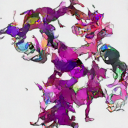
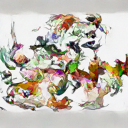
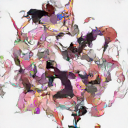
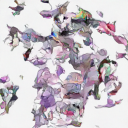
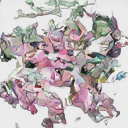
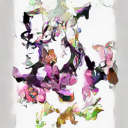
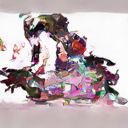
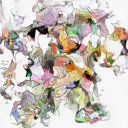
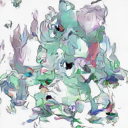
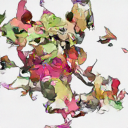
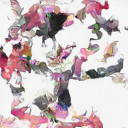
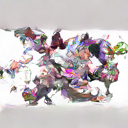

EDM Epoch 337 Loss: 0.1639 ['0.00', '0.00', '0.00', '0.16', '0.00', '0.00', '0.00', '0.00']:   9%|▉         | 112/1252 [00:02<01:08, 16.58it/s]

next display in 60 seconds


EDM Epoch 337 Loss: 0.1146 ['0.00', '0.00', '0.00', '0.00', '0.07', '0.15', '0.00', '0.00']:  11%|█         | 138/1252 [00:03<00:31, 35.25it/s]

In [ ]:
from elucidated_diffusion.models.deepseek_try3 import OptionA_FixedBottleneckUNet
m = OptionA_FixedBottleneckUNet()
rf = None # 'checkpoints/UniversalSemanticUNet_2025-12-21_20-20-50_pokemon_efficient.pth'
run_one_experiment(m,"pokemon",img_size=128,max_training_time=60*60*8,resume_from=rf)

In [ ]:
model_names = [
    # 'claude_gradual_transition', # too memory hungry at 128?
    'claude_skip_attention',
    'hybrid_cascaded_vit',
    "chatgpt_diffusion",
    'claude_semantic_coordinator',
]
for mn in model_names:
    run_one_experiment(get_model(mn,img_size),"pokemon",img_size=64,max_training_time=60*60*2)

In [ ]:
str(model_edm)

In [ ]:
try:
    train_some(model_edm,optimizer_edm,train_dataset,batch_size,train_loader,experiment_name=experiment_name, img_size=img_size)
except KeyboardInterrupt as e:
    print("done")
        

# Inference

In [ ]:
def show_model_info(model_edm):
    # Totals
    total_params = sum(p.numel() for p in model_edm.parameters())
    trainable_params = sum(p.numel() for p in model_edm.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)\n")
    
    # Breakdown by top-level module (first name segment)
    by_module = {}
    for name, p in model_edm.named_parameters():
        top = name.split('.')[0]
        tot = p.numel()
        by_module.setdefault(top, [0, 0])
        by_module[top][0] += tot
        if p.requires_grad:
            by_module[top][1] += tot
    
    # Print sorted breakdown
    print("Parameter breakdown by top-level module:")
    for mod, (tot, train) in sorted(by_module.items(), key=lambda x: x[1][0], reverse=True):
        pct = train / tot * 100 if tot else 0.0
        print(f"{mod:35} total: {tot:12,}   trainable: {train:12,}   trainable%: {pct:6.2f}")
    
    # Show largest individual parameter tensors for quick inspection
    print("\nTop 10 largest parameter tensors:")
    largest = sorted(model_edm.named_parameters(), key=lambda x: x[1].numel(), reverse=True)[:10]
    for name, p in largest:
        print(f"{name:60} shape: {tuple(p.shape)} params: {p.numel():12,}  {'train' if p.requires_grad else 'frozen'}")

show_model_info(model)

In [ ]:
model = SkipAttentionUNet().to(device)
cp = 'checkpoints/good/SkipAttentionUNet_2025-12-06_11-40-27_fantasy_efficient.pth'
load_checkpoint(model=model, optimizer=None, path=cp)
img_size=128
h = sample_html(model, img_shape=(3,img_size,img_size), title=f"EDM of {model_edm.__class__.__name__}" )
ipd.display(ipd.HTML(h))
show_model_info(model)


## Inferrence

In [ ]:

def demo_semantic_coordinator():
    img_size=128
    model_edm = create_semantic_coordinator(
        img_size=img_size,
        cnn_layers=3,        vit_layers=4,        cnn_resolution=16,        vit_resolution=16,
    ).to(device)
    cp = 'checkpoints/UnifiedSemanticCoordinatorUNet_2025-12-01_09-25-10_pokemon_efficient.pth'
    optimizer_edm = None
    load_checkpoint(model_edm, optimizer_edm, cp)
    h = sample_html(model_edm,  img_shape=(3,img_size,img_size), 
                                title=f"EDM of {model_edm.__class__.__name__}"
                                )
    ipd.display(ipd.HTML(h))
    model_edm.to('cpu')
demo_semantic_coordinator()



In [ ]:
#diffusion_weights = "checkpoints/UNet128_2025-09-08_17-57-30_cats_and_dogs.pth"
#diffusion_weights = "checkpoints/UNet128_2025-09-09_06-38-40_fantasy.pth"
#load_checkpoint(model_edm, optimizer_edm, diffusion_weights)

def generate_html_examples(cp="checkpoints/UNet128_2025-09-12_19-47-15_dragon.pth",batch_size=12, img_shape=(3,128,128)):
    with torch.no_grad():
        model_edm = UNet128(use_attention=True).to(device)
        optimizer_edm = None
        load_checkpoint(model_edm, optimizer_edm, cp)
        h = sample_html(model_edm,title=f"Samples from {cp}",min_height=1024, batch_size=batch_size, img_shape=img_shape)
        ipd.display(ipd.HTML(h))
        model_edm.to('cpu')
        



In [ ]:
cp = "checkpoints/UNet128_2025-09-14_02-20-07_fantasy.pth"
cp="checkpoints/UNet128_2025-09-12_19-47-15_dragon.pth"
generate_html_examples(cp=cp,batch_size=6,img_shape=(3,64,256))


In [ ]:
generate_html_examples(cp="checkpoints/UNet128_2025-09-14_02-09-02_dragon.pth",batch_size=6)